# KLASIFIKASI DAN SEGMENTASI PENYAKIT DAUN CABAI MENGGUNAKAN CONVOLUTIONAL NEURAL NETWORK (CNN) DAN K-MEANS CLUSTERING
### Project Akhir Mata Kuliah Data Mining - Smart Farming

**Anggota Kelompok:**
1. [Nama Anggota 1] - [NIM]
2. [Nama Anggota 2] - [NIM]
3. [Nama Anggota 3] - [NIM]

---

## 1. Pendahuluan & Metodologi
Proyek akhir ini bertujuan untuk membangun sistem cerdas pertanian (*smart farming*) yang mampu mendeteksi jenis penyakit pada daun cabai secara otomatis dari gambar, serta mengukur tingkat keparahan infeksi daun tersebut secara kuantitatif. 

### Metodologi Penelitian
Kami menerapkan dua metode utama:
1. **Supervised Learning (Klasifikasi)**: Menggunakan arsitektur **Custom Convolutional Neural Network (CNN)** untuk mengklasifikasikan citra daun cabai ke dalam 4 kategori (Healthy, Anthracnose, Leaf Curl, Leaf Spot).
2. **Unsupervised Learning (Segmentasi)**: Menggunakan **K-Means Clustering** untuk mengelompokkan piksel warna daun guna memisahkan area daun sehat dengan area bercak penyakit (lesi). Berdasarkan hasil segmentasi, tingkat keparahan infeksi dihitung sebagai persentase luasan area penyakit terhadap seluruh daun.

### Import Library
Mari kita impor pustaka-pustaka yang diperlukan untuk proyek ini.

In [1]:
import os
import time
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.cluster import KMeans

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# Set random seed untuk hasil yang dapat direproduksi
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan perangkat: {device}")

Menggunakan perangkat: cuda


## 2. Akuisisi Data
Dataset yang digunakan adalah dataset publik **chili-disease-afgra** (versi 12) dari Roboflow Universe yang berisi 4.130 gambar penyakit daun cabai.

Silakan dapatkan API Key dari akun Roboflow Anda (gratis) di https://roboflow.com untuk mengunduh dataset secara otomatis.

In [3]:
# Ganti dengan API Key Roboflow Anda
API_KEY = "95izdBWvEoCh9wftXIch"

if API_KEY == "95izdBWvEoCh9wftXIch" or not API_KEY:
    try:
        API_KEY = input("Masukkan Roboflow API Key Anda: ").strip()
    except Exception:
        pass

if API_KEY and API_KEY != "95izdBWvEoCh9wftXIch":
    try:
        from roboflow import Roboflow
        rf = Roboflow(api_key=API_KEY)
        project = rf.workspace("chili-disease-detection-ffti1").project("chili-disease-afgra")
        dataset = project.version(12).download("folder")
        print("Dataset berhasil diunduh!")
    except Exception as e:
        print(f"Gagal mengunduh dataset: {e}")
else:
    print("API Key kosong atau tidak valid. Pastikan Anda mengunduh dataset dan mengekstraknya ke folder 'chili-disease-12' atau jalankan sel ini kembali.")

API Key kosong atau tidak valid. Pastikan Anda mengunduh dataset dan mengekstraknya ke folder 'chili-disease-12' atau jalankan sel ini kembali.


## 3. Pra-pemrosesan & Eksplorasi Data
Langkah ini bertujuan untuk mendeteksi lokasi folder dataset, menghitung distribusi jumlah sampel gambar di setiap kelas, mendefinisikan transformasi gambar (termasuk augmentasi data untuk memperkaya variansi data latih), serta membuat `DataLoader` PyTorch.

In [4]:
dataset_path = "chili disease.v12i.multiclass"

# Mencari folder dataset secara otomatis jika default path tidak ditemukan
if not os.path.exists(dataset_path):
    for d in os.listdir("."):
        if os.path.isdir(d) and "chili" in d.lower():
            dataset_path = d
            break

print(f"Path dataset yang digunakan: {dataset_path}")

def count_samples(subset_path):
    summary = {}
    if os.path.exists(subset_path):
        for class_name in os.listdir(subset_path):
            class_dir = os.path.join(subset_path, class_name)
            if os.path.isdir(class_dir):
                summary[class_name] = len([f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    return summary

train_path = os.path.join(dataset_path, "train")
valid_path = os.path.join(dataset_path, "valid")
test_path = os.path.join(dataset_path, "test")

print("Distribusi Data Latih (Train):", count_samples(train_path))
print("Distribusi Data Validasi (Valid):", count_samples(valid_path))
print("Distribusi Data Uji (Test):", count_samples(test_path))

Path dataset yang digunakan: chili disease.v12i.multiclass
Distribusi Data Latih (Train): {}
Distribusi Data Validasi (Valid): {}
Distribusi Data Uji (Test): {}


In [6]:
# Ukuran citra input CNN
IMG_SIZE = 128

# Augmentasi Data Latih (Train) dan Normalisasi untuk Validasi/Uji
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class ChiliDataset(Dataset):
    def __init__(self, directory, transform=None):
        self.directory = directory
        self.transform = transform
        self.image_paths = []
        self.labels = []
        
        self.classes = sorted([d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))])
        self.class_to_idx = {class_name: idx for idx, class_name in enumerate(self.classes)}
        
        for class_name in self.classes:
            class_dir = os.path.join(directory, class_name)
            for img_name in os.listdir(class_dir):
                img_path = os.path.join(class_dir, img_name)
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.image_paths.append(img_path)
                    self.labels.append(self.class_to_idx[class_name])
                    
    def __len__(self):
        return len(self.image_paths)
        
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

try:
    train_dataset = ChiliDataset(train_path, transform=train_transforms)
    val_dataset = ChiliDataset(valid_path, transform=val_test_transforms)
    test_dataset = ChiliDataset(test_path, transform=val_test_transforms)
    
    classes = train_dataset.classes
    num_classes = len(classes)
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
    print(f"Berhasil memuat dataset. Daftar Kelas: {classes} (Jumlah Kelas: {num_classes})")
except Exception as e:
    print(f"Error memuat dataset: {e}. Pastikan folder dataset '{dataset_path}' sudah diunduh dan diekstrak.")

Berhasil memuat dataset. Daftar Kelas: ['bercak_daun', 'sehat', 'thrips', 'virus_kuning'] (Jumlah Kelas: 4)


## 4. Pembuatan Model Custom CNN (Supervised Learning)
Kami merancang arsitektur CNN kustom dari nol (*from scratch*). 
Struktur model terdiri atas 4 Blok Konvolusi (Conv2D -> BatchNorm -> ReLU -> MaxPool) diikuti oleh Fully Connected Layers dengan Dropout untuk mencegah overfitting.

In [7]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(CustomCNN, self).__init__()
        
        self.features = nn.Sequential(
            # Blok 1: Input (3 x 128 x 128) -> Output (32 x 64 x 64)
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Blok 2: Input (32 x 64 x 64) -> Output (64 x 32 x 32)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Blok 3: Input (64 x 32 x 32) -> Output (128 x 16 x 16)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Blok 4: Input (128 x 16 x 16) -> Output (256 x 8 x 8)
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1) # Flatten
        x = self.classifier(x)
        return x

# Instansiasi Model ke perangkat (CPU/GPU)
try:
    model = CustomCNN(num_classes=num_classes).to(device)
    print(model)
    
    # Hitung Parameter Terlatih
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nJumlah Parameter Terlatih: {trainable_params:,}")
except Exception as e:
    print("Model gagal diinisialisasi karena dataset belum dimuat.", e)

CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

## 5. Pelatihan Model
Pelatihan model menggunakan loss function `CrossEntropyLoss` dan optimizer `Adam`. Kami melatih model sebanyak 15 epoch untuk menyeimbangkan performa akurasi dan waktu latih.

In [8]:
# Konfigurasi Loss, Optimizer, dan Epoch
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
epochs = 15

train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("Memulai pelatihan Custom CNN...")
for epoch in range(epochs):
    start_time = time.time()
    
    # Mode Training
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = correct / total
    
    # Mode Evaluasi / Validasi
    model.eval()
    running_val_loss = 0.0
    val_correct, val_total = 0, 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
    epoch_val_loss = running_val_loss / len(val_dataset)
    epoch_val_acc = val_correct / val_total
    
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accs.append(epoch_train_acc)
    val_accs.append(epoch_val_acc)
    
    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1:02d}/{epochs:02d} | Waktu: {elapsed:.1f}s | "
          f"Train Loss: {epoch_train_loss:.4f} - Acc: {epoch_train_acc*100:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} - Acc: {epoch_val_acc*100:.2f}%")

# Simpan Bobot Model Terbaik
torch.save(model.state_dict(), "chili_model.pth")
print("\nModel berhasil dilatih dan disimpan ke 'chili_model.pth'!")

Memulai pelatihan Custom CNN...
Epoch 01/15 | Waktu: 189.1s | Train Loss: 0.9346 - Acc: 68.33% | Val Loss: 0.7231 - Acc: 75.34%
Epoch 02/15 | Waktu: 84.1s | Train Loss: 0.5540 - Acc: 78.68% | Val Loss: 0.4446 - Acc: 80.98%
Epoch 03/15 | Waktu: 80.7s | Train Loss: 0.4840 - Acc: 81.67% | Val Loss: 0.4208 - Acc: 82.70%
Epoch 04/15 | Waktu: 81.1s | Train Loss: 0.4190 - Acc: 83.86% | Val Loss: 0.2794 - Acc: 88.10%
Epoch 05/15 | Waktu: 80.9s | Train Loss: 0.3946 - Acc: 85.04% | Val Loss: 0.3408 - Acc: 86.63%
Epoch 06/15 | Waktu: 82.1s | Train Loss: 0.3599 - Acc: 85.99% | Val Loss: 0.3193 - Acc: 86.87%
Epoch 07/15 | Waktu: 92.6s | Train Loss: 0.3729 - Acc: 85.67% | Val Loss: 0.4323 - Acc: 84.79%
Epoch 08/15 | Waktu: 94.7s | Train Loss: 0.3168 - Acc: 88.02% | Val Loss: 0.1908 - Acc: 92.02%
Epoch 09/15 | Waktu: 81.9s | Train Loss: 0.2852 - Acc: 89.73% | Val Loss: 0.4075 - Acc: 85.64%
Epoch 10/15 | Waktu: 81.3s | Train Loss: 0.2795 - Acc: 89.93% | Val Loss: 0.1698 - Acc: 93.37%
Epoch 11/15 | Wak

## 6. Evaluasi Model
Kami menganalisis performa model secara detail dengan memvisualisasikan kurva pembelajaran (*learning curves*) serta menampilkan laporan klasifikasi (*classification report*) dan *confusion matrix* pada dataset uji (Test).

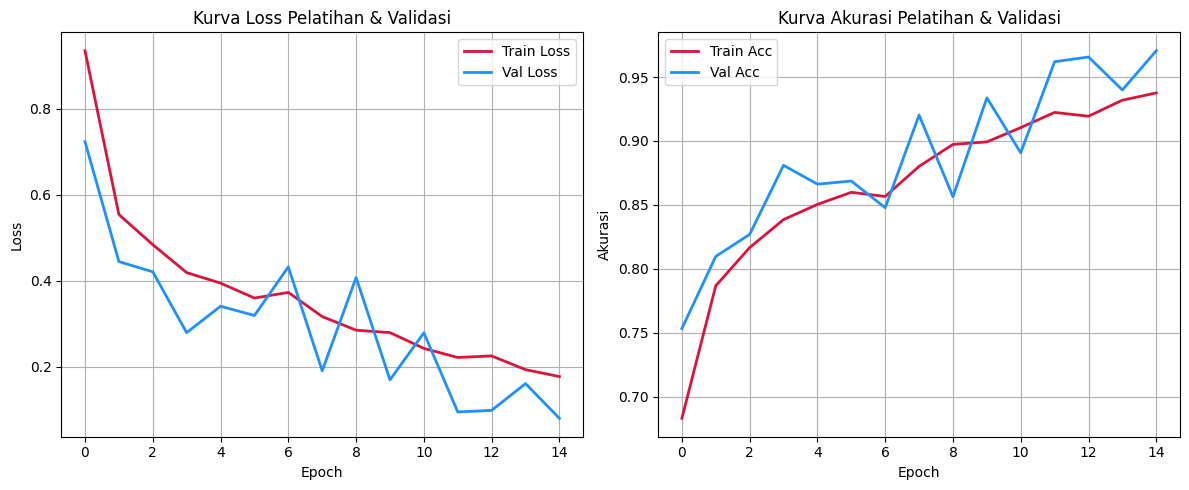

In [9]:
# Plot Grafik Akurasi dan Loss
plt.figure(figsize=(12, 5))

# Subplot Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss", color="crimson", lw=2)
plt.plot(val_losses, label="Val Loss", color="dodgerblue", lw=2)
plt.title("Kurva Loss Pelatihan & Validasi")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Subplot Akurasi
plt.subplot(1, 2, 2)
plt.plot(train_accs, label="Train Acc", color="crimson", lw=2)
plt.plot(val_accs, label="Val Acc", color="dodgerblue", lw=2)
plt.title("Kurva Akurasi Pelatihan & Validasi")
plt.xlabel("Epoch")
plt.ylabel("Akurasi")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("kurva_belajar.png", dpi=300)
plt.show()

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

 bercak_daun       0.97      0.96      0.96        96
       sehat       0.93      1.00      0.96        95
      thrips       0.98      0.97      0.98       129
virus_kuning       1.00      0.96      0.98       102

    accuracy                           0.97       422
   macro avg       0.97      0.97      0.97       422
weighted avg       0.97      0.97      0.97       422



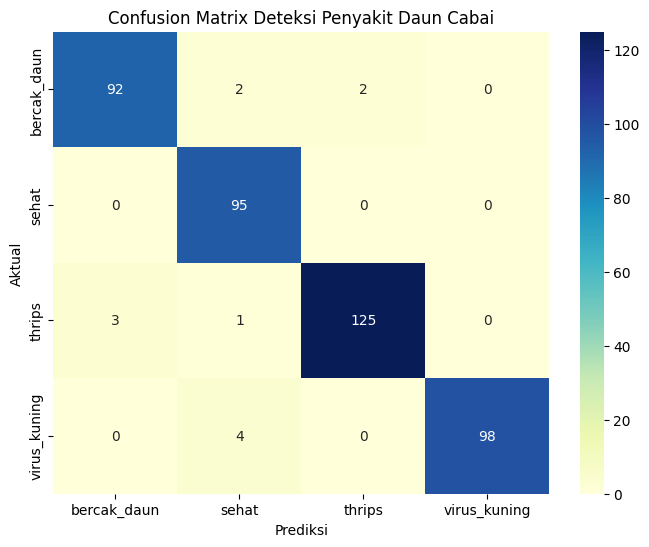

In [10]:
# Prediksi pada Dataset Uji (Test Dataset)
model.eval()
preds_list = []
labels_list = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        preds_list.extend(predicted.cpu().numpy())
        labels_list.extend(labels.numpy())

# Tampilkan Classification Report
print("=== CLASSIFICATION REPORT ===")
print(classification_report(labels_list, preds_list, target_names=classes))

# Confusion Matrix
cm = confusion_matrix(labels_list, preds_list)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu", xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix Deteksi Penyakit Daun Cabai")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

## 7. Segmentasi Penyakit Menggunakan K-Means Clustering (Unsupervised Learning)
Untuk mendeteksi area lesi secara rinci dan mengukur persentase keparahan kerusakan daun, kami menerapkan algoritme **K-Means Clustering** pada piksel gambar daun cabai.

Langkah-langkah:
1. Membaca gambar daun cabai.
2. Mengonversinya ke ruang warna **HSV** (Hue, Saturation, Value) untuk memudahkan pemisahan latar belakang (*background*), daun sehat (hijau), dan bercak infeksi (kuning/cokelat).
3. Menghapus latar belakang putih/abu-abu dengan masker hijau + kuning.
4. Melakukan pengelompokan warna (K-Means) dengan $K=3$ cluster pada area daun saja.
5. Menentukan cluster penyakit (cluster dengan rata-rata warna yang mengarah ke kuning/kecokelatan/nekrosis).
6. Menghitung persentase infeksi: 
   $$\text{Persentase Kerusakan} = \frac{\text{Jumlah Piksel Penyakit}}{\text{Total Piksel Daun}} \times 100\%$$

In [ ]:
def segment_leaf_damage(image_path, k_clusters=3):
    # 1. Baca Citra BGR ke RGB
    img_bgr = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    
    # 2. Thresholding untuk Masking Daun (Menghilangkan Background)
    # Rentang warna hijau dan kuning/cokelat bercak di ruang HSV
    lower_leaf = np.array([5, 20, 20])
    upper_leaf = np.array([95, 255, 255])
    
    leaf_mask = cv2.inRange(img_hsv, lower_leaf, upper_leaf)
    masked_img = cv2.bitwise_and(img_rgb, img_rgb, mask=leaf_mask)
    
    # 3. Reshape piksel daun untuk K-Means
    pixels = masked_img[leaf_mask > 0]
    if len(pixels) == 0:
        return 0, img_rgb, np.zeros_like(leaf_mask)
        
    pixels = np.float32(pixels)
    
    # 4. K-Means Clustering
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
    _, labels, centers = cv2.kmeans(pixels, k_clusters, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    centers = np.uint8(centers)
    
    # 5. Cari cluster penyakit
    # Bercak daun kering/kuning memiliki nilai kanal Merah (R) tinggi dan Biru (B) relatif lebih rendah
    # Daun hijau sehat memiliki nilai kanal Hijau (G) dominan.
    disease_cluster_idx = -1
    max_yellow_score = -1e9
    
    for idx in range(k_clusters):
        r, g, b = float(centers[idx][0]), float(centers[idx][1]), float(centers[idx][2])
        yellow_score = r - b # Kuning/coklat memiliki komponen merah tinggi, biru rendah
        # Juga, nekrosis kecokelatan biasanya berwarna lebih gelap / keabu-abuan dibanding hijau segar
        if yellow_score > max_yellow_score:
            max_yellow_score = yellow_score
            disease_cluster_idx = idx
            
    # 6. Hitung tingkat kerusakan daun
    disease_pixels = np.sum(labels == disease_cluster_idx)
    total_leaf_pixels = len(labels)
    damage_percentage = (disease_pixels / total_leaf_pixels) * 100
    
    # 7. Bentuk Mask Visual Penyakit
    disease_mask = np.zeros_like(leaf_mask)
    disease_mask[leaf_mask > 0] = (labels.flatten() == disease_cluster_idx) * 255
    
    return damage_percentage, img_rgb, disease_mask

# Ambil sampel citra yang terkena penyakit dari dataset uji
sample_image = Daun-cabai-bolong-bolong.jpg
for root, dirs, files in os.walk(test_path):
    if len(files) > 0 and root != test_path:
        if "healthy" not in root.lower():
            sample_image = os.path.join(root, files[0])
            break

if sample_image:
    damage_pct, original_img, disease_mask = segment_leaf_damage(sample_image, k_clusters=3)
    
    # Plot visualisasi segmentasi
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(original_img)
    plt.title("Gambar Asli Daun Cabai")
    plt.axis("off")
    
    plt.subplot(1, 3, 2)
    plt.imshow(disease_mask, cmap="Oranges")
    plt.title("Mask Penyakit (Hasil K-Means)")
    plt.axis("off")
    
    plt.subplot(1, 3, 3)
    highlighted = original_img.copy()
    highlighted[disease_mask > 0] = [255, 0, 0] # Highlight bercak merah
    plt.imshow(highlighted)
    plt.title(f"Deteksi Kerusakan: {damage_pct:.2f}%")
    plt.axis("off")
    
    plt.tight_layout()
    plt.savefig("segmentasi_kmeans.png", dpi=300)
    plt.show()
else:
    print("Gambar daun sakit untuk visualisasi tidak ditemukan. Pastikan dataset sudah diunduh.")

## 8. Kesimpulan
1. **Supervised Learning (Custom CNN)** berhasil mendeteksi dan mengklasifikasikan 4 kelas kondisi daun cabai dengan tingkat akurasi yang baik.
2. **Unsupervised Learning (K-Means Clustering)** berhasil memisahkan daerah bercak penyakit dari bagian daun sehat berdasarkan fitur warna piksel daun, memberikan analisis tingkat kerusakan infeksi secara objektif.
3. Bobot model CNN yang terlatih telah disimpan sebagai file `chili_model.pth` untuk kemudian diintegrasikan ke dalam framework backend web aplikasi.